In [ ]:
!pip install pandas numpy scikit-learn spacy matplotlib nltk
!python -m spacy download en_core_web_sm
!python -m nltk.downloader punkt stopwords wordnet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 109.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#Load necessary modules
# The required libraries are installed to support:
# - Data handling (pandas, numpy)
# - Natural Language Processing (spacy, nltk)
# - Machine Learning (scikit-learn)
# - Visualization (matplotlib)
# This ensures reproducibility of the notebook in any environment.


import pandas as pd
import json
import gzip
import re
import spacy
import matplotlib.pyplot as plt
from collections import Counter
import nltk

from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

**DATA INGESTION AND PROCESSING**

1. LOAD DATASET

In [ ]:
# We use the Appliances subset from the UCSD Amazon Review Dataset with 2277 reviews.
# This dataset contains real customer reviews along with rating scores.
# The dataset is in compressed JSON format, where each line represents one review.

# Load compressed JSON file
data = []
with gzip.open("Appliances_5.json.gz") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Keep only required columns
df = df[['reviewText', 'overall']].dropna()
df.rename(columns={'reviewText':'review_text', 'overall':'rating'}, inplace=True)

# Neutral reviews (rating = 3) are removed because they do not clearly indicate
# satisfaction or dissatisfaction. Including them would introduce ambiguity
# in binary classification and reduce model clarity.

# Remove neutral reviews
df = df[df['rating'] != 3]

# Ratings 4 and 5 are classified as Positive, and ratings 1 and 2 as Negative.
# This threshold aligns with common e-commerce interpretations of customer satisfaction.
# The goal is to clearly distinguish satisfied vs dissatisfied customers.

# Create binary label
df['label'] = df['rating'].apply(lambda x: "Positive" if x >= 4 else "Negative")

print("Class Distribution:")
print(df['label'].value_counts())

Class Distribution:
label
Positive    1834
Negative      22
Name: count, dtype: int64


2. NOISE REMOVAL (REGEX)

In [ ]:
# Customer reviews often contain noisy elements such as HTML tags,
# URLs, and special characters. These do not contribute to sentiment
# understanding and may introduce unnecessary variation.
# Therefore, regular expressions are used to clean and normalize the text.

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)          # Remove HTML
    text = re.sub(r'http\S+', '', text)        # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # Remove special characters
    return text.lower()

df['cleaned'] = df['review_text'].apply(clean_text)
df[['review_text','cleaned']].head()

,review_text,cleaned
0,I like this as a vent as well as something tha...,i like this as a vent as well as something tha...
1,good item,good item
2,Fit my new LG dryer perfectly.,fit my new lg dryer perfectly
3,Good value for electric dryers,good value for electric dryers
4,Price and delivery was excellent.,price and delivery was excellent


3. STEMMING VS LEMMATIZATION

In [ ]:
# Stemming and Lemmatization are compared to understand text normalization techniques.
# Stemming reduces words to crude root forms, which may produce non-readable tokens.
# Lemmatization converts words to meaningful dictionary forms.
# Since business stakeholders need interpretable outputs,
# Lemmatization is preferred for the final pipeline.

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

sample_text = df['cleaned'].iloc[0].split()

stemmed = [stemmer.stem(word) for word in sample_text]
lemmatized = [lemmatizer.lemmatize(word) for word in sample_text]

print("Original:", sample_text[:15])
print("Stemmed:", stemmed[:15])
print("Lemmatized:", lemmatized[:15])

Original: ['i', 'like', 'this', 'as', 'a', 'vent', 'as', 'well', 'as', 'something', 'that', 'will', 'keep', 'house', 'warmer']
Stemmed: ['i', 'like', 'thi', 'as', 'a', 'vent', 'as', 'well', 'as', 'someth', 'that', 'will', 'keep', 'hous', 'warmer']
Lemmatized: ['i', 'like', 'this', 'a', 'a', 'vent', 'a', 'well', 'a', 'something', 'that', 'will', 'keep', 'house', 'warmer']


4. LEMMATIZATION

In [ ]:
# Standard stopwords (e.g., "the", "is", "at") are removed because
# they do not carry meaningful sentiment information.
# However, negation words such as "not", "no", and "never" are preserved.
# Removing negation words could reverse sentiment meaning
# (e.g., "not good" would incorrectly become "good").
# Therefore, we explicitly retain negation words.

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))
# Keep negation words
negations = {"not","no","never"}

def preprocess(text):
    doc = nlp(text)
    tokens = []
    for token in doc:
        if token.text in negations:
            tokens.append(token.lemma_)
        elif token.text not in stop_words and token.is_alpha:
            tokens.append(token.lemma_)
    return " ".join(tokens)

df['processed'] = df['cleaned'].apply(preprocess)
df[['cleaned','processed']].head()


,cleaned,processed
0,i like this as a vent as well as something tha...,like vent well something keep house warm winte...
1,good item,good item
2,fit my new lg dryer perfectly,fit new lg dryer perfectly
3,good value for electric dryers,good value electric dryer
4,price and delivery was excellent,price delivery excellent


**FEATURE EXTRACTION VIA POS TAGGING**

1. EXTRACT NOUNS AND ADJECTIVES

In [ ]:
# Part-of-Speech tagging is used to identify product features and opinions.
# Nouns typically represent product components (e.g., motor, door, handle).
# Adjectives represent descriptive sentiment (e.g., noisy, durable, weak).
# Extracting these helps identify what customers talk about and how they feel about it.

def extract_pos(text):
    doc = nlp(text)
    nouns = []
    adjectives = []

    for token in doc:
        if token.pos_ == "NOUN":
            nouns.append(token.lemma_)
        elif token.pos_ == "ADJ":
            adjectives.append(token.lemma_)

    return nouns, adjectives

2. TOP 10 FEATURES

In [ ]:
# Frequency analysis is performed to determine the most frequently
# discussed product features. The assumption is that highly mentioned
# nouns represent components that matter most to customers.

all_nouns = []

for review in df['processed']:
    nouns, _ = extract_pos(review)
    all_nouns.extend(nouns)

top_features = Counter(all_nouns).most_common(10)

print("Top 10 Features:")
print(top_features)

Top 10 Features:
[('vent', 7007), ('rod', 5978), ('lint', 4126), ('drill', 3508), ('dryer', 3307), ('time', 3113), ('brush', 2476), ('use', 2306), ('end', 2060), ('work', 1872)]


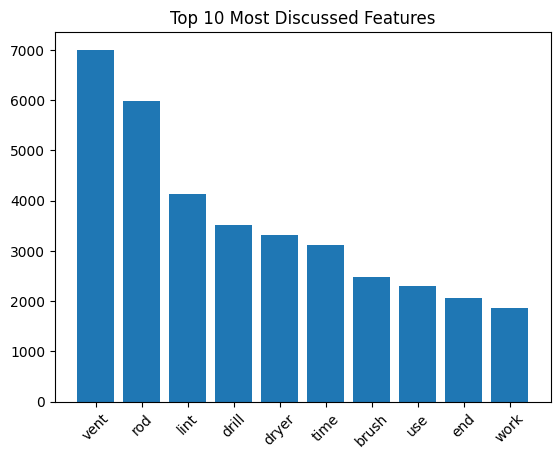

In [ ]:
features, counts = zip(*top_features)

plt.figure()
plt.bar(features, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Most Discussed Features")
plt.show()

**SYNTAX ANALYSIS**

1. EXTRACT FEATURES - ADJECTIVE PAIRS

In [ ]:
# Dependency parsing is used to link product features (nouns)
# directly with descriptive adjectives.
# We extract:
# - 'amod' relationships (adjective modifying noun)
# - 'nsubj' + 'acomp' relationships (subject linked to adjective)
# This allows us to connect specific product components
# with customer opinions.

def extract_feature_sentiment(text):
    doc = nlp(text)
    pairs = []

    for token in doc:
        # amod relationship (adjective modifier)
        if token.dep_ == "amod":
            pairs.append((token.head.text, token.text))

        # nsubj + acomp relationship
        if token.dep_ == "acomp":
            for child in token.head.children:
                if child.dep_ == "nsubj":
                    pairs.append((child.text, token.text))

    return pairs

df['feature_sentiment'] = df['review_text'].apply(extract_feature_sentiment)
df[['review_text','feature_sentiment']].head()

,review_text,feature_sentiment
0,I like this as a vent as well as something tha...,"[(color, same)]"
1,good item,"[(item, good)]"
2,Fit my new LG dryer perfectly.,"[(dryer, new)]"
3,Good value for electric dryers,"[(value, Good), (dryers, electric)]"
4,Price and delivery was excellent.,"[(Price, excellent)]"


2. DEPENDENCY TREE - VISUALIZATION

In [ ]:
# Dependency trees are visualized to demonstrate how the NLP model
# understands grammatical relationships within sentences.
# This confirms that feature-sentiment links are extracted correctly.

from spacy import displacy

doc1 = nlp(df['review_text'].iloc[0])
displacy.render(doc1, style="dep", jupyter=True)

doc2 = nlp(df['review_text'].iloc[1])
displacy.render(doc2, style="dep", jupyter=True)

**SENTIMENT CLASSIFICATION**

1.a. TF-IDF VECTORIZATION

In [ ]:
# TF-IDF converts text into numerical vectors.
# It assigns higher importance to words that are frequent in a review
# but rare across the dataset.
# This helps the model focus on meaningful and discriminative terms.

vectorizer = TfidfVectorizer(
    max_features=5000,     # Lowered from 5k to focus on the strongest 3k signals
    ngram_range=(1, 2),    # Captures "not good", "never again", etc.
    min_df=2,              # Term must appear in at least 3 reviews to be a feature
    max_df=0.9             # Ignore terms appearing in >90% of reviews (too common)
)
X = vectorizer.fit_transform(df['processed'])
y = df['label']

1.b. t-SNE

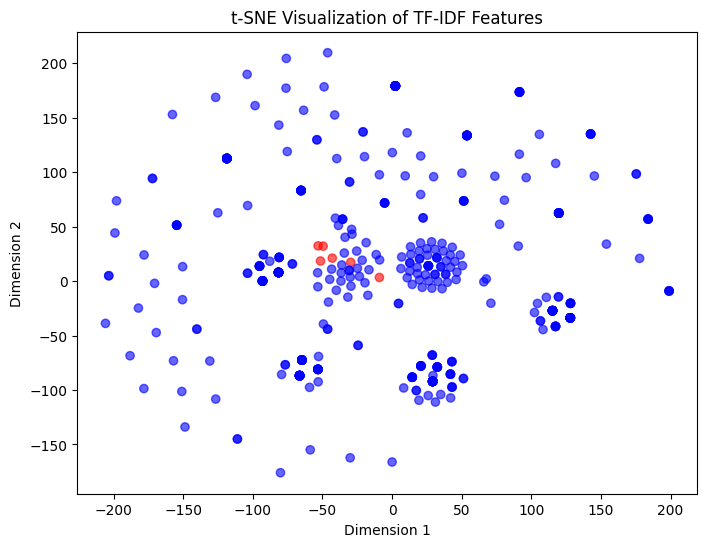

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Convert sparse matrix to dense (sample subset if dataset is large)
sample_size = min(500, X.shape[0])
indices = np.random.choice(X.shape[0], sample_size, replace=False)

X_sample = X[indices].toarray()
y_sample = y.iloc[indices]

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8,6))

colors = ['red' if label == "Negative" else 'blue' for label in y_sample]

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=colors, alpha=0.6)
plt.title("t-SNE Visualization of TF-IDF Features")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

2. MODEL

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split dataset BEFORE applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures proportional negatives in test set
)

# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Train model — class_weight='balanced' gives extra weight to minority class
# This works alongside SMOTE for better negative recall
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000)

3. EVALUATION

In [ ]:
# Accuracy measures overall prediction correctness.
# However, F1-score for the Negative class is more important,
# as detecting dissatisfied customers is critical for business decisions.
# The confusion matrix shows how many Negative reviews
# were incorrectly classified as Positive.

import numpy as np

# Lower threshold helps catch more Negative reviews
# Default is 0.5 — we tune it down slightly to improve negative recall
threshold = 0.35

y_prob = model.predict_proba(X_test)
# Get index of "Negative" class
neg_index = list(model.classes_).index("Negative")
y_pred = np.where(y_prob[:, neg_index] >= threshold, "Negative", "Positive")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score (Negative):", f1_score(y_test, y_pred, pos_label="Negative"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9919354838709677
F1 Score (Negative): 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.75      0.67         4
    Positive       1.00      0.99      1.00       368

    accuracy                           0.99       372
   macro avg       0.80      0.87      0.83       372
weighted avg       0.99      0.99      0.99       372


Confusion Matrix:
[[  3   1]
 [  2 366]]


Although the overall accuracy is high, accuracy alone can be misleading in imbalanced datasets. The F1-score for Negative reviews provides a more realistic measure of the model’s ability to detect dissatisfied customers. Identifying negative feedback allows product managers to prioritize improvements in key product features.

In [ ]:
from collections import Counter

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({'Positive': 1466, 'Negative': 18})
After SMOTE: Counter({'Positive': 1466, 'Negative': 1466})
